In [30]:
import os
import torch
import numpy as np
import random

def seed_everything(seed):
    """
    Set random seed for reproducibility
    """
    # 1. Python & Numpy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"🔒 Locked Random Seed: {seed}")


In [31]:



def seed_everything_random():
    """
    Tạo random seed, set seed đó, và return seed để bạn biết
    """
    # Tạo random seed
    random_seed = random.randint(0, 999999)
    
    # Set seed
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    # Để reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    return random_seed


In [32]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [33]:
#load data
df_men =pd.read_csv(r"/home/ducvu0904/Documents/Lab/RERUM/dataset/Hillstrom-Men.csv")
df_men = df_men.drop(columns="Unnamed: 0")
print ("---------------------------")
print ("null count:")
print (df_men.isnull().sum())
print ("---------------------------")
print(df_men.dtypes)
print ("---------------------------")
print ("labels:")
print(df_men.columns.tolist())
print ("---------------------------")
print("data shape:")
print(df_men.shape)
print("spend")

---------------------------
null count:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
visit              0
conversion         0
spend              0
treatment          0
dtype: int64
---------------------------
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object
---------------------------
labels:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'visit', 'conversion', 'spend', 'treatment']
---------------------------
data shape:
(42613, 12)
spend


In [34]:
#Hillstrom-men
#split num and cate
cate_cols = ['zip_code', 'channel', 'history_segment']
num_cols = ['recency', 'history']

#split x y t
y_men = df_men["spend"]
t_men = df_men["treatment"]
x_men = df_men.drop(columns=["spend", "treatment", "visit", "conversion"])

# Tạo biến stratify kết hợp: treatment x purchase (y > 0)
stratify_combined = t_men.astype(str) + "_" + (y_men > 0).astype(int).astype(str)

#train test split - stratify bằng treatment x purchase
x_men_train, x_men_test, t_men_train, t_men_test, y_men_train, y_men_test = train_test_split(
    x_men, t_men.values, y_men.values,
    test_size=0.3, random_state=42, stratify=stratify_combined
)

# Tạo stratify cho val split - treatment x purchase
stratify_var_train = pd.Series(t_men_train).astype(str) + "_" + (pd.Series(y_men_train) > 0).astype(int).astype(str)

x_men_train, x_men_val, t_men_train, t_men_val, y_men_train, y_men_val = train_test_split(
    x_men_train, t_men_train, y_men_train,
    test_size=(1/7), random_state=42, stratify=stratify_var_train
)

# y_men_train = np.log1p(y_men_train)
# y_men_val = np.log1p(y_men_val)

# Fit get_dummies trên train, sau đó align với val/test
x_men_train_encode = pd.get_dummies(x_men_train, columns=cate_cols, drop_first=False)
x_men_val_encode = pd.get_dummies(x_men_val, columns=cate_cols, drop_first=False)
x_men_test_encode = pd.get_dummies(x_men_test, columns=cate_cols, drop_first=False)

# Align columns
x_men_val_encode = x_men_val_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)
x_men_test_encode = x_men_test_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)

scaler = StandardScaler()
x_men_train= scaler.fit_transform(x_men_train_encode)
x_men_val = scaler.transform(x_men_val_encode)
x_men_test = scaler.transform(x_men_test_encode)

print ("✅ Train/Val/Test split with stratification by TREATMENT x PURCHASE")
print (f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print (f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print (f"Purchase rate - Train: {np.mean(y_men_train > 0):.2%}, Val: {np.mean(y_men_val > 0):.2%}, Test: {np.mean(y_men_test > 0):.2%}")
print (f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")

✅ Train/Val/Test split with stratification by TREATMENT x PURCHASE
Train: (25567, 18), Val: (4262, 18), Test: (12784, 18)
Treatment distribution - Train: 50.00%, Val: 50.00%, Test: 50.00%
Purchase rate - Train: 0.91%, Val: 0.92%, Test: 0.92%
Spend mean - Train: 1.06, Val: 1.05, Test: 0.99


In [35]:
#Transform to tensor
def to_tensor(df):
    return torch.tensor(df, dtype=torch.float32)

x_men_train_t = to_tensor(x_men_train)
x_men_val_t = to_tensor(x_men_val)
x_men_test_t = to_tensor(x_men_test)

y_men_train_t = to_tensor(y_men_train).unsqueeze(1)
y_men_val_t = to_tensor(y_men_val).unsqueeze(1)
y_men_test_t = to_tensor(y_men_test).unsqueeze(1)

t_men_train_t = to_tensor(t_men_train.astype(float)).unsqueeze(1)
t_men_val_t = to_tensor(t_men_val.astype(float)).unsqueeze(1)
t_men_test_t = to_tensor(t_men_test.astype(float)).unsqueeze(1)

# sampler = get_sampler(y_men_train_t, target_positive_ratio=0.2)

#Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 6400
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print ("-------------------------------------------------------------")
print ("✅Completed tranform to tensor✅")
print (f"Shape of train: x={x_men_train_t.shape}; y ={y_men_train_t.shape}; t={t_men_train_t.shape}")
print (f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print (f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅Completed tranform to tensor✅
Shape of train: x=torch.Size([25567, 18]); y =torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 18]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 18]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


Evaluation metrics

In [36]:
from metrics import auuc, auqc, lift, krcc

Build Model

In [37]:
from dragonnet import Dragonnet

In [38]:
print("📊 Data Distribution Check:")
print(f"Y train: mean={y_men_train.mean():.4f}, std={y_men_train.std():.4f}")
print(f"Y train zeros: {(y_men_train == 0).sum()} / {len(y_men_train)} ({(y_men_train == 0).sum()/len(y_men_train)*100:.1f}%)")
print(f"\nTreatment balance:")
print(f"  Train: {(t_men_train == 1).sum()} treated, {(t_men_train == 0).sum()} control")
print(f"  Test:  {(t_men_test == 1).sum()} treated, {(t_men_test == 0).sum()} control")

📊 Data Distribution Check:
Y train: mean=1.0596, std=15.0603
Y train zeros: 25334 / 25567 (99.1%)

Treatment balance:
  Train: 12784 treated, 12783 control
  Test:  6392 treated, 6392 control


In [39]:
def compute_ate(y, t):
    y = np.asarray(y).reshape(-1)
    t = np.asarray(t).reshape(-1)
    treated = y[t == 1]
    control = y[t == 0]
    return treated.mean() - control.mean()

ate_train = compute_ate(y_men_train, t_men_train)
ate_val = compute_ate(y_men_val, t_men_val)
ate_test = compute_ate(y_men_test, t_men_test)

print(f"ATE (Train): {ate_train:.6f}")
print(f"ATE (Val):   {ate_val:.6f}")
print(f"ATE (Test):  {ate_test:.6f}")

ATE (Train): 0.828667
ATE (Val):   0.963970
ATE (Test):  0.587423


In [40]:
epochs =50
alpha = 1
beta = 0
lr = 5e-4
wd = 1e-5
early_stop_metric = "qini"
ema = True
ema_alpha = 0.15
patience = 15
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start_epoch = 0
print (f" epochs = {epochs}")
print (f" alpha = {alpha}")
print (f" beta = {beta}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" share dropout = {shared_dropout}")
print (f" outcome dropout = {outcome_droupout}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")

 epochs = 50
 alpha = 1
 beta = 0
 learning rate = 0.0005
 weight decay = 1e-05
 early stop = qini
 use ema = True
 ema alpha = 0.15
 patience = 15
 share dropout = 0
 outcome dropout = 0
 shared hidden = 200
 outcome hidden = 100


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Base Loss: 386.2119 | Tarreg Loss: 0.000000 | Total Loss: 386.2119 | Val Loss: 499.3204 | Raw Qini: 0.6398 | EMA Trend: 0.6398 | ⭐ NEW BEST (peak ≥ trend)


Epoch 2/50 | Base Loss: 270.0151 | Tarreg Loss: 0.000000 | Total Loss: 270.0151 | Val Loss: 498.8867 | Raw Qini: 0.7764 | EMA Trend: 0.6602 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Base Loss: 463.5129 | Tarreg Loss: 0.000000 | Total Loss: 463.5129 | Val Loss: 498.1215 | Raw Qini: 0.7978 | EMA Trend: 0.6809 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/50 | Base Loss: 602.2966 | Tarreg Loss: 0.000000 | Total Loss: 602.2966 | Val Loss: 496.8484 | Raw Qini: 0.8046 | EMA Trend: 0.6994 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/50 | Base Loss: 391.8665 | Tarreg Loss: 0.000000 | Total Loss: 391.8665 | Val Loss: 495.8903 | Raw Qini: 0.8375 | EMA Trend: 0.7201 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/50 | Base Loss: 582.0082 | Tarreg Loss: 0.000000 | Total Loss: 582.0082 | Val Loss: 495.7735 | Raw Qini: 0.8669 | EMA Trend: 0.7422 | ⭐ NEW BEST (peak ≥ trend)
Epoch 7/50 | Base Loss: 573.1872 | Tarreg Loss: 0.000000 | Total Loss: 573.1872 | Val Loss: 495.5914 | Raw Qini: 0.8684 | EMA Trend: 0.7611 | ⭐ NEW BEST (peak ≥

/home/ducvu0904/Documents/Lab/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


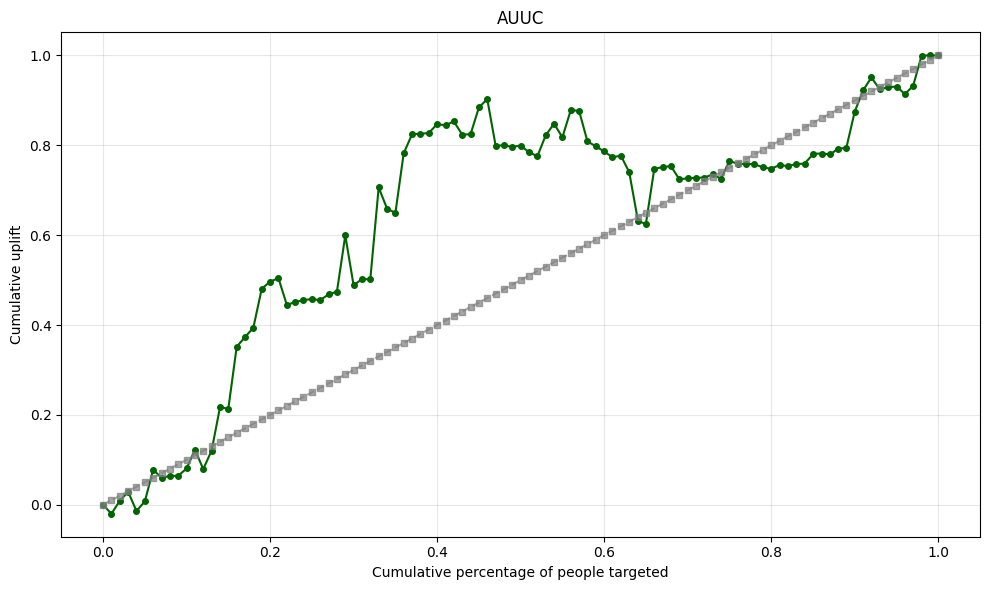

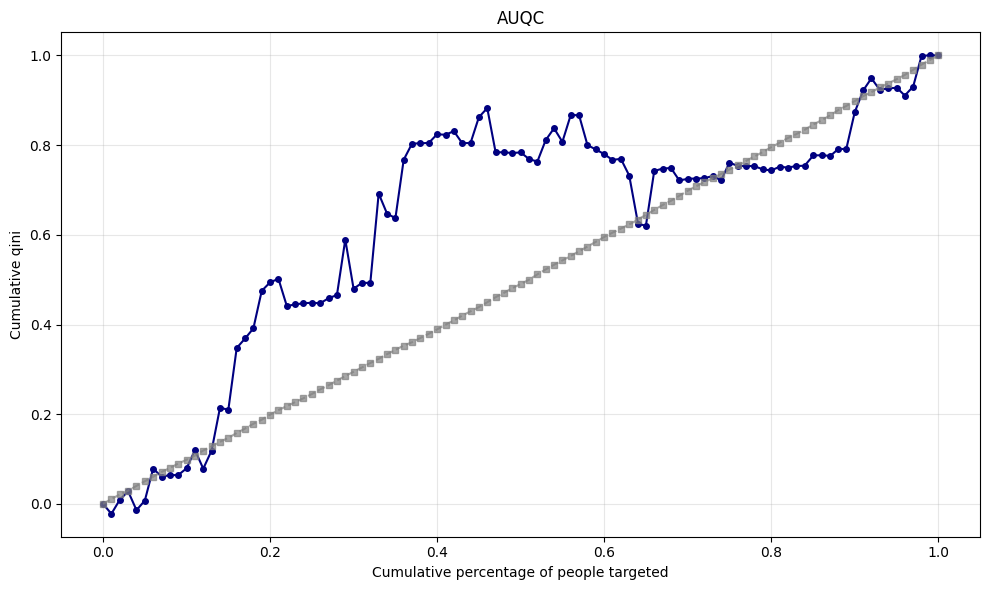

----------------------------------------
AUUC: 0.632
AUQC: 0.625
Lift: 0.957
KRCC: 0.078
seed: 412312


In [41]:
seed = 412312
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Base Loss: 421.5824 | Tarreg Loss: 0.000000 | Total Loss: 421.5824 | Val Loss: 499.1414 | Raw Qini: 0.4423 | EMA Trend: 0.4423 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Base Loss: 498.2385 | Tarreg Loss: 0.000000 | Total Loss: 498.2385 | Val Loss: 498.7692 | Raw Qini: 0.5525 | EMA Trend: 0.4588 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Base Loss: 452.3363 | Tarreg Loss: 0.000000 | Total Loss: 452.3363 | Val Loss: 498.1318 | Raw Qini: 0.6898 | EMA Trend: 0.4934 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/50 | Base Loss: 604.5974 | Tarreg Loss: 0.000000 | Total Loss: 604.5974 | Val Loss: 497.1632 | Raw Qini: 0.7717 | EMA Trend: 0.5352 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/50 | Base Loss: 409.3635 | Tarreg Lo

Epoch 18/50 | Base Loss: 511.3121 | Tarreg Loss: 0.000000 | Total Loss: 511.3121 | Val Loss: 495.5170 | Raw Qini: 0.6837 | EMA Trend: 0.7434 | (patience: 9/15)
Epoch 19/50 | Base Loss: 609.0215 | Tarreg Loss: 0.000000 | Total Loss: 609.0215 | Val Loss: 495.5909 | Raw Qini: 0.6076 | EMA Trend: 0.7230 | (patience: 10/15)
Epoch 20/50 | Base Loss: 393.5058 | Tarreg Loss: 0.000000 | Total Loss: 393.5058 | Val Loss: 495.6096 | Raw Qini: 0.5308 | EMA Trend: 0.6942 | (patience: 11/15)
Epoch 21/50 | Base Loss: 408.4373 | Tarreg Loss: 0.000000 | Total Loss: 408.4373 | Val Loss: 495.6294 | Raw Qini: 0.4770 | EMA Trend: 0.6616 | (patience: 12/15)
Epoch 22/50 | Base Loss: 376.5213 | Tarreg Loss: 0.000000 | Total Loss: 376.5213 | Val Loss: 495.7263 | Raw Qini: 0.4498 | EMA Trend: 0.6298 | (patience: 13/15)
Epoch 23/50 | Base Loss: 226.3380 | Tarreg Loss: 0.000000 | Total Loss: 226.3380 | Val Loss: 495.7798 | Raw Qini: 0.4094 | EMA Trend: 0.5968 | (patience: 14/15)
Epoch 24/50 | Base Loss: 388.9276 |

/home/ducvu0904/Documents/Lab/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


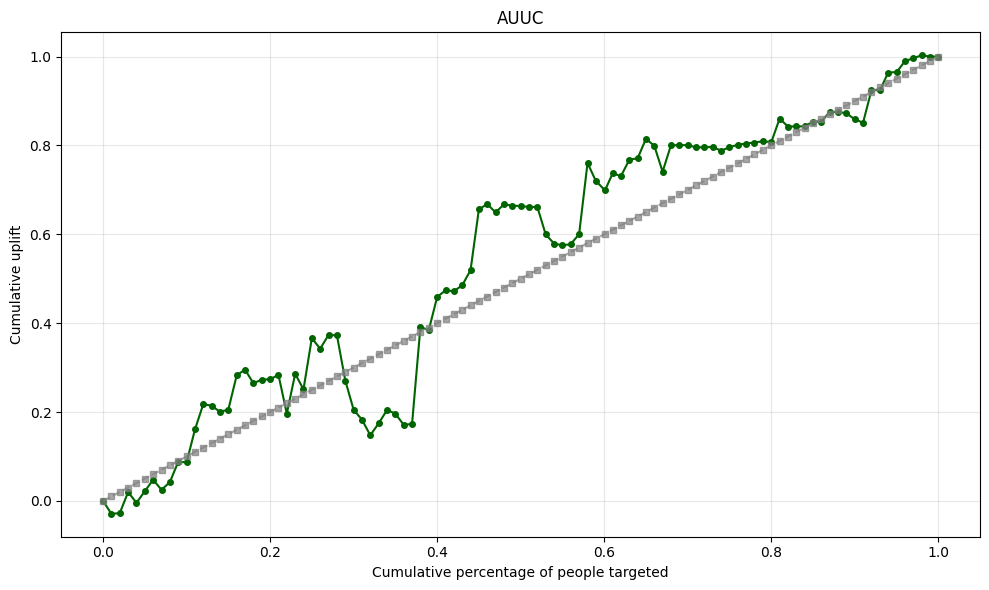

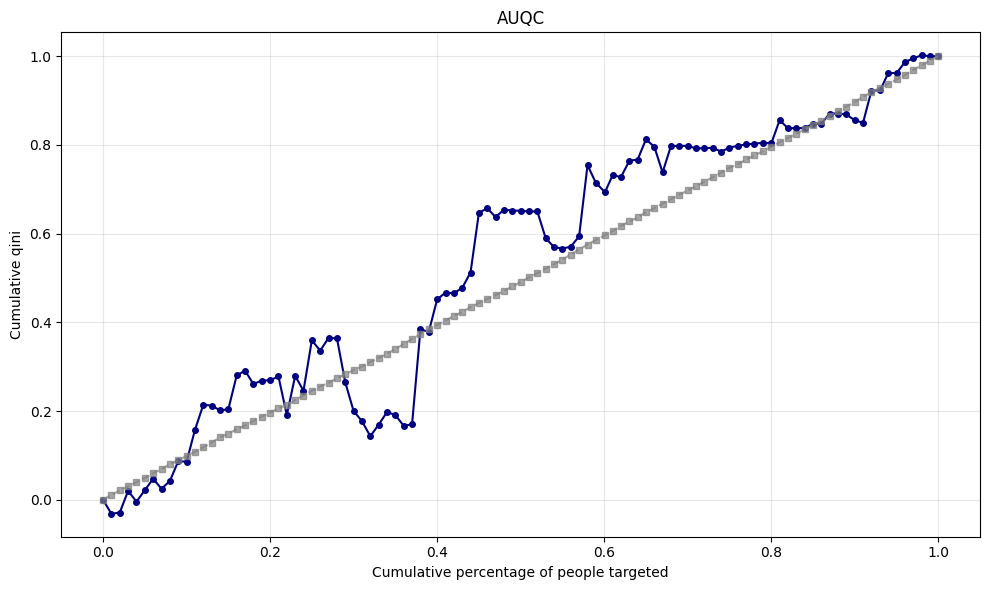

----------------------------------------
AUUC: 0.539
AUQC: 0.534
Lift: 0.403
KRCC: -0.001
seed: 42


In [42]:
seed = 42
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Base Loss: 709.0958 | Tarreg Loss: 0.000000 | Total Loss: 709.0958 | Val Loss: 499.1700 | Raw Qini: 0.3122 | EMA Trend: 0.3122 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Base Loss: 400.7067 | Tarreg Loss: 0.000000 | Total Loss: 400.7067 | Val Loss: 498.6858 | Raw Qini: 0.7509 | EMA Trend: 0.3780 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Base Loss: 329.2198 | Tarreg Loss: 0.000000 | Total Loss: 329.2198 | Val Loss: 497.8449 | Raw Qini: 0.7979 | EMA Trend: 0.4410 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/50 | Base Loss: 664.8726 | Tarreg Loss: 0.000000 | Total Loss: 664.8726 | Val Loss: 496.6484 | Raw Qini: 0.8003 | EMA Trend: 0.4949 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/50 | Base Loss: 310.7177 | Tarreg 

Epoch 9/50 | Base Loss: 480.3336 | Tarreg Loss: 0.000000 | Total Loss: 480.3336 | Val Loss: 496.1804 | Raw Qini: 0.8111 | EMA Trend: 0.6752 | ✓ above trend but not peak (patience: 2/15)
Epoch 10/50 | Base Loss: 441.9862 | Tarreg Loss: 0.000000 | Total Loss: 441.9862 | Val Loss: 496.0195 | Raw Qini: 0.8080 | EMA Trend: 0.6951 | ✓ above trend but not peak (patience: 3/15)
Epoch 11/50 | Base Loss: 533.7351 | Tarreg Loss: 0.000000 | Total Loss: 533.7351 | Val Loss: 495.7635 | Raw Qini: 0.8047 | EMA Trend: 0.7116 | ✓ above trend but not peak (patience: 4/15)
Epoch 12/50 | Base Loss: 550.7816 | Tarreg Loss: 0.000000 | Total Loss: 550.7816 | Val Loss: 495.6786 | Raw Qini: 0.8019 | EMA Trend: 0.7251 | ✓ above trend but not peak (patience: 5/15)
Epoch 13/50 | Base Loss: 382.2953 | Tarreg Loss: 0.000000 | Total Loss: 382.2953 | Val Loss: 495.6412 | Raw Qini: 0.7921 | EMA Trend: 0.7352 | ✓ above trend but not peak (patience: 6/15)
Epoch 14/50 | Base Loss: 638.9224 | Tarreg Loss: 0.000000 | Total 

/home/ducvu0904/Documents/Lab/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


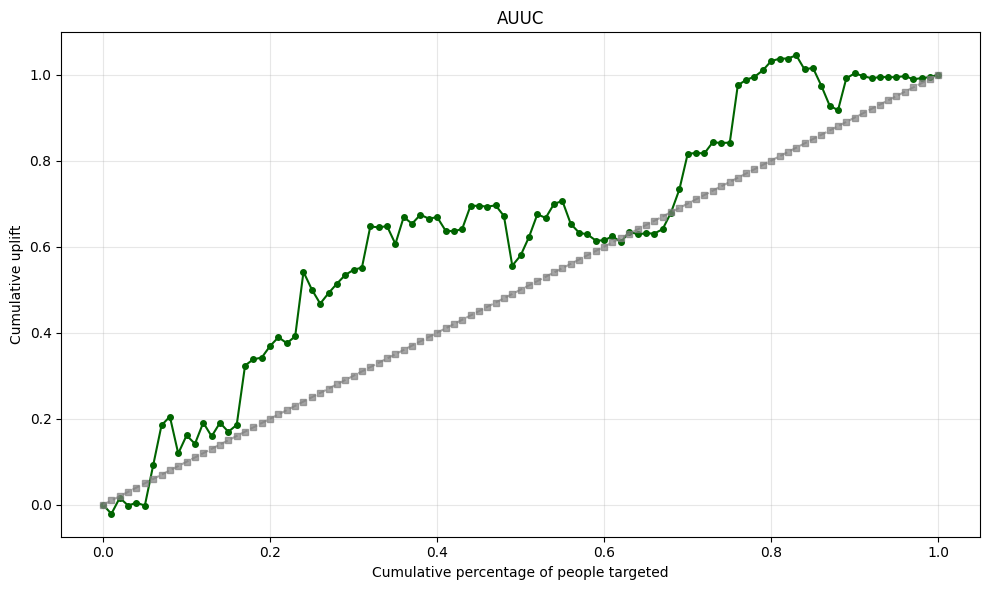

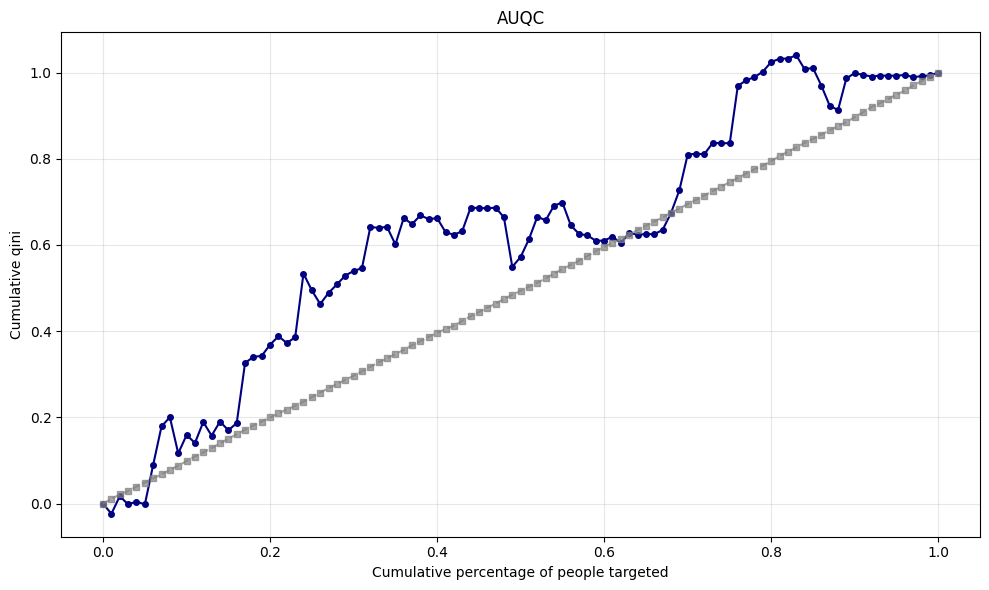

----------------------------------------
AUUC: 0.625
AUQC: 0.621
Lift: 1.070
KRCC: 0.050
seed: 1874


In [43]:
seed = 1874
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Base Loss: 635.5238 | Tarreg Loss: 0.000000 | Total Loss: 635.5238 | Val Loss: 499.2080 | Raw Qini: 0.5114 | EMA Trend: 0.5114 | ⭐ NEW BEST (peak ≥ trend)


Epoch 2/50 | Base Loss: 388.1028 | Tarreg Loss: 0.000000 | Total Loss: 388.1028 | Val Loss: 498.8134 | Raw Qini: 0.7213 | EMA Trend: 0.5429 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Base Loss: 469.6457 | Tarreg Loss: 0.000000 | Total Loss: 469.6457 | Val Loss: 498.1260 | Raw Qini: 0.6681 | EMA Trend: 0.5617 | ✓ above trend but not peak (patience: 1/15)
Epoch 4/50 | Base Loss: 497.7497 | Tarreg Loss: 0.000000 | Total Loss: 497.7497 | Val Loss: 497.0728 | Raw Qini: 0.6690 | EMA Trend: 0.5778 | ✓ above trend but not peak (patience: 2/15)
Epoch 5/50 | Base Loss: 607.3893 | Tarreg Loss: 0.000000 | Total Loss: 607.3893 | Val Loss: 496.4183 | Raw Qini: 0.7023 | EMA Trend: 0.5965 | ✓ above trend but not peak (patience: 3/15)
Epoch 6/50 | Base Loss: 446.7407 | Tarreg Loss: 0.000000 | Total Loss: 446.7407 | Val Loss: 496.4051 | Raw Qini: 0.7261 | EMA Trend: 0.6159 | ⭐ NEW BEST (peak ≥ trend)
Epoch 7/50 | Base Loss: 409.8874 | Tarreg Loss: 0.000000 | Total Loss: 409.8874 | Val Loss: 495.9471 | Raw

/home/ducvu0904/Documents/Lab/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


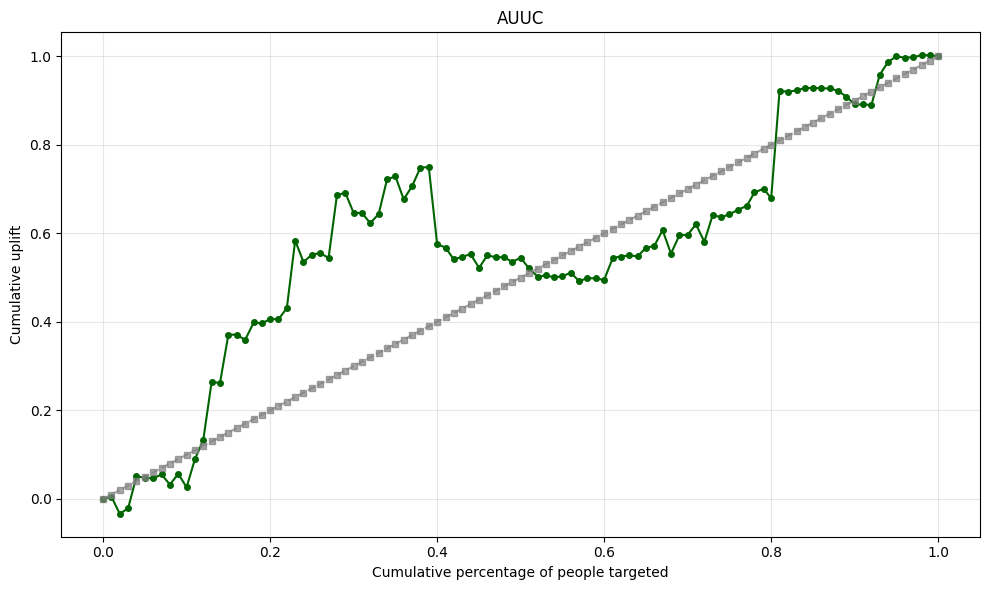

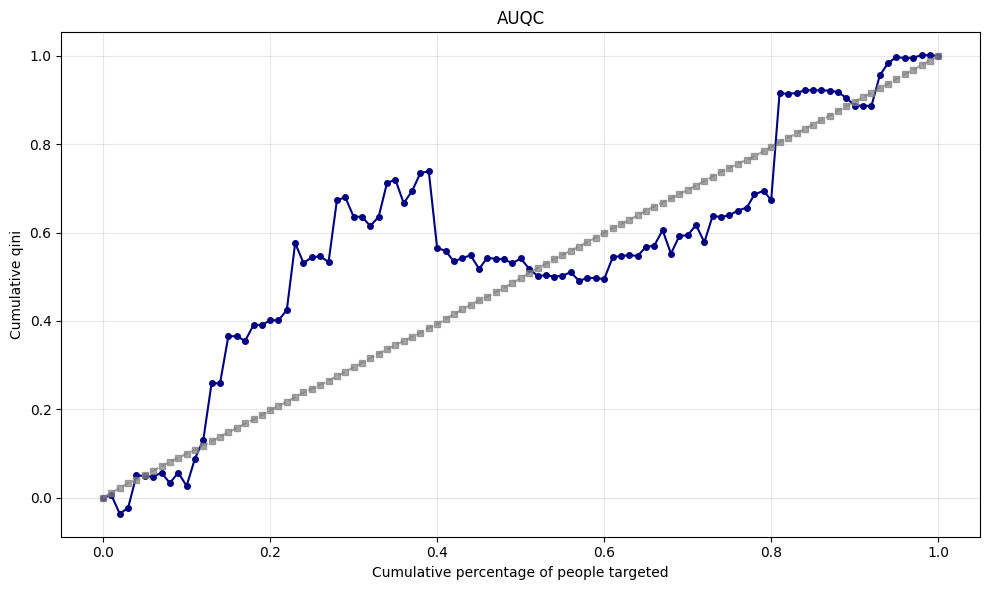

----------------------------------------
AUUC: 0.569
AUQC: 0.564
Lift: 1.266
KRCC: 0.044
seed: 902745


In [44]:
seed = 902745
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")     

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Base Loss: 457.0794 | Tarreg Loss: 0.000000 | Total Loss: 457.0794 | Val Loss: 499.5934 | Raw Qini: 0.5864 | EMA Trend: 0.5864 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Base Loss: 373.9606 | Tarreg Loss: 0.000000 | Total Loss: 373.9606 | Val Loss: 499.1507 | Raw Qini: 0.3889 | EMA Trend: 0.5568 | (patience: 1/15)
Epoch 3/50 | Base Loss: 368.0550 | Tarreg Loss: 0.000000 | Total Loss: 368.0550 | Val Loss: 498.3442 | Raw Qini: 0.4261 | EMA Trend: 0.5372 | (patience: 2/15)
Epoch 4/50 | Base Loss: 281.3656 | Tarreg Loss: 0.000000 | Total Loss: 281.3656 | Val Loss: 497.0641 | Raw Qini: 0.7299 | EMA Trend: 0.5661 | ⭐ NEW BEST (peak ≥ trend)


Epoch 5/50 | Base Loss: 285.0427 | Tarreg Loss: 0.000000 | Total Loss: 285.0427 | Val Loss: 496.1205 | Raw Qini: 0.8238 | EMA Trend: 0.6047 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/50 | Base Loss: 604.6235 | Tarreg Loss: 0.000000 | Total Loss: 604.6235 | Val Loss: 495.6522 | Raw Qini: 0.8353 | EMA Trend: 0.6393 | ⭐ NEW BEST (peak ≥ trend)
Epoch 7/50 | Base Loss: 461.5935 | Tarreg Loss: 0.000000 | Total Loss: 461.5935 | Val Loss: 495.5102 | Raw Qini: 0.8419 | EMA Trend: 0.6697 | ⭐ NEW BEST (peak ≥ trend)
Epoch 8/50 | Base Loss: 630.4656 | Tarreg Loss: 0.000000 | Total Loss: 630.4656 | Val Loss: 495.4403 | Raw Qini: 0.8400 | EMA Trend: 0.6953 | ✓ above trend but not peak (patience: 1/15)
Epoch 9/50 | Base Loss: 672.8168 | Tarreg Loss: 0.000000 | Total Loss: 672.8168 | Val Loss: 495.4243 | Raw Qini: 0.8295 | EMA Trend: 0.7154 | ✓ above trend but not peak (patience: 2/15)
Epoch 10/50 | Base Loss: 622.7826 | Tarreg Loss: 0.000000 | Total Loss: 622.7826 | Val Loss: 495.4648 | Raw Qini: 0.8151 | E

/home/ducvu0904/Documents/Lab/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


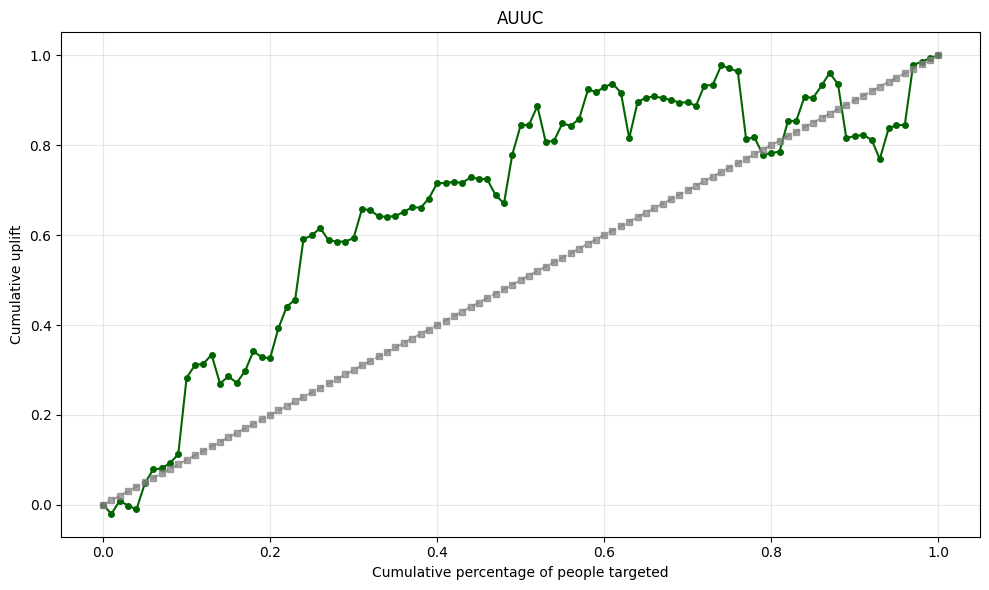

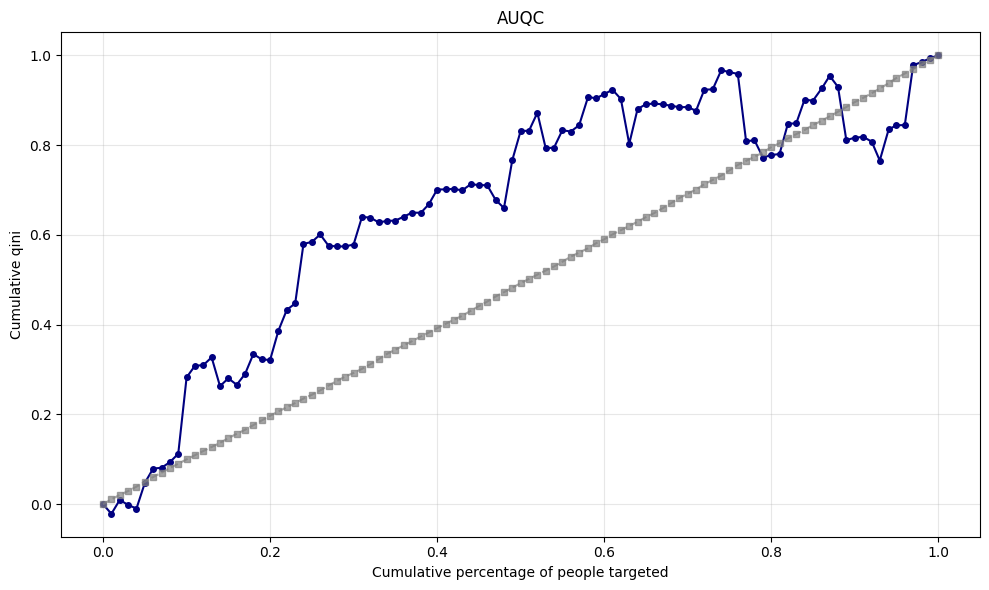

----------------------------------------
AUUC: 0.668
AUQC: 0.659
Lift: 1.162
KRCC: 0.072
seed: 1


In [45]:
seed = 1
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")